## Learning Objectives

By the end of this notebook, you will be able to:
- Prepare a cleaned text dataset for clustering and quick baselines.
- Build dense embeddings for program descriptions.
- Run KMeans + TSNE to explore how well clusters align with human categories.
- Train a simple multinomial logistic regression to benchmark supervised performance.
- Read confusion matrices to spot strong/weak categories.

## Dataset Case Study: My CHI My Future (MCMF) Programs in Chicago

<p style="display: flex; justify-content: center; align-items: center;">
    <img src="images/cropped-cropped-Final-Logo-1.png" alt="MCDC Logo" style="width: 20%; height: auto; margin-right: 2%;">
    <img src="images/mcmf_logo.png" alt="MCMF Logo" style="width: 20%; height: auto;">
</p>

This case study explores real-world data from the My CHI My Future (MCMF) youth programs in Chicago. The dataset was selected for the [MCDC](https://sites.northwestern.edu/mcdc/) practicum course (Spring 2023, Dr. Lizhen Shi) in partnership with [My CHI My Future](https://explore.mychimyfuture.org/) and community leader Stender Von Oehsen. The project aimed to address real community needs through data science, with results featured on the [MCDC Past Projects website](https://sites.northwestern.edu/mcdc/projects/).

**Context:**

- The MCMF initiative, led by the City of Chicago, connects youth to thousands of out-of-school programs, events, and resources across the city.
- The dataset includes detailed information about program names, descriptions, categories, dates, and locations, providing a rich resource for text analysis and feature engineering.
- Students worked with community partners to clean, analyze, and model this data, supporting efforts to improve youth engagement and access to opportunities.

This notebook demonstrates how to preprocess and analyze text data from a real civic dataset, preparing it for downstream modeling and actionable insights. This lesson was co-developed by **Dr. Lizhen Shi** and **Dr. Arend Kuyper** for the MCDC pathway courses (Summer 2025). 

### What this notebook covers
1) Load the cleaned text dataset from the text analysis cleanup notebook.
2) Keep the top categories and cap records per category to balance training.
3) Build embeddings, cluster with KMeans, and visualize with TSNE.
4) Compare clusters to human labels (purity tables).
5) Train a quick supervised baseline and review its confusion matrix.

In [1]:
import pandas as pd
import numpy as np

## Guided Practice

### Load the cleaned dataset
We reuse `datasets/data_cleaned_20250826.csv` produced by the cleanup notebook so we can focus on clustering rather than preprocessing.

In [2]:
df = pd.read_csv('datasets/data_cleaned_20250826.csv', low_memory=False)
df = df[df['Description_Clean'].str.len() > 25]
df['program_name'] = df['Program Name']
df['category_name'] = df['Category Name']
df['description'] = df['Description_Clean']
df = df[['program_name', 'category_name', 'description']].reset_index(drop=True)
df.head()

,program_name,category_name,description
0,Homework Help: Virtual Teacher in the Library,Music & Art.,get homework help certified teacher library re...
1,Art of Storytelling Learning Circle,Academic Support,makes good story developed pixar storys struct...
2,Learn American Sign Language,Academic Support,want brush american thurgood marshall branch w...
3,Learn American Sign Language,Academic Support,want brush american thurgood marshall branch w...
4,The Harold Washington Experience: Historians R...,Academic Support,april harold washington history becoming chica...


### Focus on the most common categories
Limit to the top 5 categories to keep clusters interpretable and avoid extreme class imbalance.

In [7]:
top_categories = df.groupby('category_name').size().sort_values(ascending=False).head(5).index.to_list()
df = df[df['category_name'].isin(top_categories)].reset_index(drop=True)
df.shape

(283936, 3)

### Cap records per category
Downsample very large categories (up to 5k each) so clustering is not dominated by a few labels and runs quickly.

In [9]:
# sample each category by 5000
df = df.groupby('category_name').apply(lambda x: x.sample(min(len(x), 5000), random_state=42)).reset_index(drop=True)
df.shape

/var/folders/mf/1cxc46zs15d1fymjh2ngf42w0000gp/T/ipykernel_1264/167447334.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('category_name').apply(lambda x: x.sample(min(len(x), 5000), random_state=42)).reset_index(drop=True)


(25000, 3)

In [10]:
df['category_name'].value_counts()

category_name
Academic Support      5000
Music & Art.          5000
Reading & Writing.    5000
Science               5000
Sports + Wellness.    5000
Name: count, dtype: int64

### Inspect description length
Check description length distribution to choose a reasonable token cutoff for embeddings.

<Axes: >

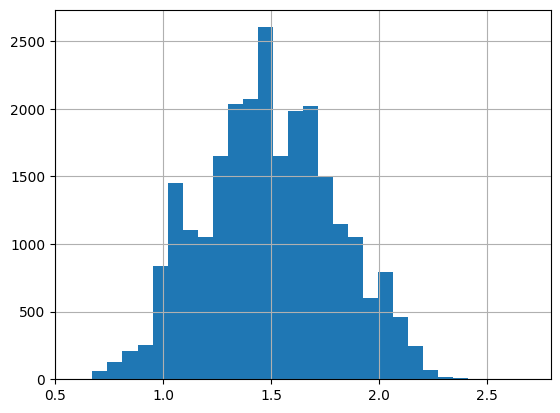

In [11]:
df['description'].map(lambda s: np.log10(len(s.split()))).hist(bins=30)

In [12]:
description_cutoff = 30

We will truncate each description to the first 30 tokens when creating embeddings to standardize input length.

### Create text embeddings
Generate dense vectors for each description using `fastembed.TextEmbedding`; truncation keeps runtime manageable.

In [13]:
 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
import numpy as np
from fastembed import TextEmbedding

embedding_model = TextEmbedding()

embedding_matrix = list(embedding_model.embed(df['description'].map(lambda s: " ".join(s.split()[:description_cutoff]))))


In [14]:
embedding_matrix = np.array(embedding_matrix)
embedding_matrix.shape

(25000, 384)

### Cluster embeddings with KMeans
Run KMeans (k=5) on the embedding matrix and project to 2D with SVD for a quick visual check.

Shape of TF-IDF matrix: (25000, 384)


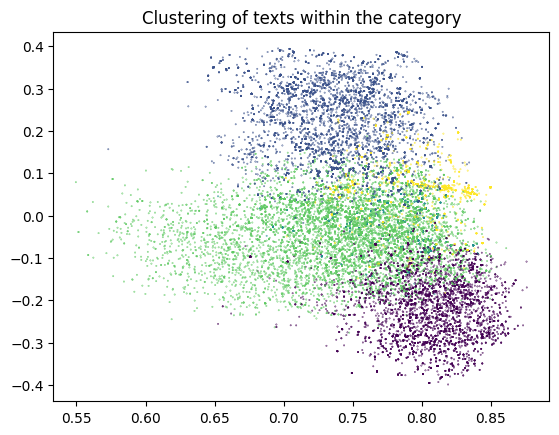

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Suppose you already have:
# tfidf_matrix = vectorizer.fit_transform(docs)

# 1. Look at basic info
print("Shape of TF-IDF matrix:", embedding_matrix.shape)  # (num_docs, num_terms)

# 2. Cluster the docs
n_clusters = 5  # you can adjust or use silhouette score to find a good k
km = KMeans(n_clusters=n_clusters, random_state=42)
clusters = km.fit_predict(embedding_matrix)


# 3. Dimensionality reduction for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
reduced = svd.fit_transform(embedding_matrix)

plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap="viridis", s=0.1)
plt.title("Clustering of texts within the category")
plt.show()
 

### Visualize with TSNE
Use TSNE to see the same embeddings in a non-linear 2D space; color by KMeans labels to inspect separation.

In [60]:
from openTSNE import TSNE

embedding = TSNE(n_jobs=-1).fit(embedding_matrix)
embedding.shape

(25000, 2)

### Compare clusters vs. true categories
Overlay cluster labels against the original categories to eyeball alignment.

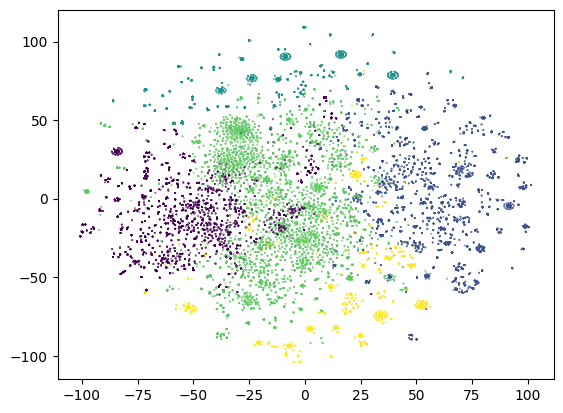

In [72]:
labels = df['category_name'].astype('category').cat.codes.values
plt.scatter(embedding[:, 0], embedding[:, 1], c=clusters, cmap="viridis", s=0.1)

In [ ]:
df['cluster'] = clusters
df['cluster'].value_counts()

### Cluster purity table
Cross-tab clusters with true categories to see which categories each cluster captures (row-normalized and column-normalized views follow).

In [22]:
confusion_matrix = df.groupby(['category_name','cluster']).size().unstack(fill_value=0)
confusion_matrix    

cluster,0,1,2,3,4
category_name,,,,,
Academic Support,181,134,2377,620,1688
Music & Art.,602,500,1,3505,392
Reading & Writing.,3331,6,11,1558,94
Science,865,1303,3,2823,6
Sports + Wellness.,1,4326,0,151,522


In [34]:
# Define a function to highlight values > 0.4
def highlight_greater_than(s, threshold=0.4):
    is_greater = s > threshold
    return ['background-color: green' if v else '' for v in is_greater]


In [35]:
confusion_matrix.div(confusion_matrix.sum(axis=1), axis=0).style.apply(highlight_greater_than)

cluster,0,1,2,3,4
category_name,,,,,
Academic Support,0.036200,0.026800,0.475400,0.124000,0.337600
Music & Art.,0.120400,0.100000,0.000200,0.701000,0.078400
Reading & Writing.,0.666200,0.001200,0.002200,0.311600,0.018800
Science,0.173000,0.260600,0.000600,0.564600,0.001200
Sports + Wellness.,0.000200,0.865200,0.000000,0.030200,0.104400


In [36]:
confusion_matrix.div(confusion_matrix.sum(axis=0), axis=1).style.apply(highlight_greater_than, axis=0)

cluster,0,1,2,3,4
category_name,,,,,
Academic Support,0.036345,0.021375,0.993729,0.071618,0.624722
Music & Art.,0.120884,0.079758,0.000418,0.404875,0.145078
Reading & Writing.,0.668876,0.000957,0.004599,0.179970,0.034789
Science,0.173695,0.207848,0.001254,0.326094,0.002221
Sports + Wellness.,0.000201,0.690062,0.000000,0.017443,0.193190


In [40]:
df['category_label'] = df['category_name'].astype('category').cat.codes
df['category_label'].value_counts()

category_label
4    5000
1    5000
3    5000
2    5000
0    5000
Name: count, dtype: int64

### Train/test split for a supervised baseline
Shuffle the balanced subset and hold out 20% for testing a simple classifier.

In [43]:
df=df.sample(frac=1).reset_index(drop=True)  # shuffle the dataframe
train_df = df[:int(0.8*len(df))]
test_df = df[int(0.8*len(df)):]
train_df.shape,test_df.shape

((20000, 5), (5000, 5))

In [45]:
train_df['category_label'].value_counts(),\
test_df['category_label'].value_counts()

(category_label
 0    4042
 2    4037
 1    4013
 4    3960
 3    3948
 Name: count, dtype: int64,
 category_label
 3    1052
 4    1040
 1     987
 2     963
 0     958
 Name: count, dtype: int64)

### Embed train/test descriptions
Reuse the same embedding model and token cutoff to vectorize both train and test splits.

In [46]:
train_X = list(embedding_model.embed(train_df['description'].map(lambda s: " ".join(s.split()[:description_cutoff]))))
test_X = list(embedding_model.embed(test_df['description'].map(lambda s: " ".join(s.split()[:description_cutoff]))))
train_y = train_df['category_label'].to_list()
test_y = test_df['category_label'].to_list()

### Train a multinomial logistic regression
Fit a quick linear classifier as a baseline for how well categories can be recovered from embeddings.

In [47]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs')
clf.fit(train_X, train_y)

/Users/R8C6026/mydev/mcdc_2025su/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [49]:
test_predictions = clf.predict(test_X)

In [52]:
label_to_category = dict(enumerate(df['category_name'].astype('category').cat.categories))

### Evaluate with a confusion matrix
Map predictions back to category names and inspect normalized confusion matrices to spot strong/weak classes.

In [53]:
confusion_matrix = pd.crosstab(pd.Series(test_y, name='Actual'), pd.Series(test_predictions, name='Predicted'))
confusion_matrix.index = confusion_matrix.index.map(label_to_category)
confusion_matrix.columns = confusion_matrix.columns.map(label_to_category)
confusion_matrix

Predicted,Academic Support,Music & Art.,Reading & Writing.,Science,Sports + Wellness.
Actual,,,,,
Academic Support,899,29,5,14,11
Music & Art.,33,826,45,45,38
Reading & Writing.,6,30,906,20,1
Science,2,32,3,1010,5
Sports + Wellness.,15,23,1,13,988


In [57]:
confusion_matrix.div(confusion_matrix.sum(axis=1),axis=0).style.apply(highlight_greater_than)

Predicted,Academic Support,Music & Art.,Reading & Writing.,Science,Sports + Wellness.
Actual,,,,,
Academic Support,0.938413,0.030271,0.005219,0.014614,0.011482
Music & Art.,0.033435,0.836879,0.045593,0.045593,0.038501
Reading & Writing.,0.006231,0.031153,0.940810,0.020768,0.001038
Science,0.001901,0.030418,0.002852,0.960076,0.004753
Sports + Wellness.,0.014423,0.022115,0.000962,0.012500,0.950000


In [58]:
confusion_matrix.div(confusion_matrix.sum(axis=0),axis=1).style.apply(highlight_greater_than)

Predicted,Academic Support,Music & Art.,Reading & Writing.,Science,Sports + Wellness.
Actual,,,,,
Academic Support,0.941361,0.030851,0.005208,0.012704,0.010547
Music & Art.,0.034555,0.878723,0.046875,0.040835,0.036433
Reading & Writing.,0.006283,0.031915,0.943750,0.018149,0.000959
Science,0.002094,0.034043,0.003125,0.916515,0.004794
Sports + Wellness.,0.015707,0.024468,0.001042,0.011797,0.947267


## Wrap-up
You clustered program descriptions using embeddings, inspected cluster purity against human labels, and trained a simple classifier baseline. Use these diagnostics to decide whether to tune k, adjust the stoplist/token cutoff, or try richer models.